# Task 1.1 — Offering Strategy under One-Price Balancing Scheme

We determine the optimal day-ahead (DA) offering strategy for a price-taking wind farm under uncertainty.

---

## Decision Variable

$$
p_t^{DA}
$$

- Power offered in the day-ahead market at hour $t$

---

## Profit per Scenario

For each scenario $\omega$, profit is:

$$
\Pi_{t,\omega} =
p_t^{DA} \cdot \lambda^{DA}_{t,\omega}
+
\left(W_{t,\omega} - p_t^{DA}\right) \cdot \lambda^{B}_{t,\omega}
$$

where:
- $W_{t,\omega}$ = realized wind power  
- $\lambda^{DA}_{t,\omega}$ = day-ahead price  
- $\lambda^{B}_{t,\omega}$ = balancing price  

---

## One-Price Scheme

Under the one-price scheme:

- All imbalances are settled at the balancing price
- No distinction between helpful or harmful deviations

Balancing prices are defined as:

$$
\lambda^{B}_{t,\omega} =
\begin{cases}
1.25 \cdot \lambda^{DA}_{t,\omega}, & \text{if system deficit} \\
0.85 \cdot \lambda^{DA}_{t,\omega}, & \text{if system surplus}
\end{cases}
$$

---

## Objective Function

We maximize expected profit:

$$
\max \mathbb{E}[\Pi] =
\frac{1}{|\Omega|} \sum_{\omega \in \Omega} \sum_{t=1}^{24} \Pi_{t,\omega}
$$

---

## Constraints

$$
0 \leq p_t^{DA} \leq P_{\max}
$$

for all hours $t$.

---

## Notes

- The wind farm is a price-taker
- All scenarios are equally likely
- Total scenarios: $20 \times 20 \times 4 = 1600$

In [10]:
# ============================================
# TASK 1.1 — ONE-PRICE OPTIMIZATION
# ============================================

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB

# ----------------------------
# LOAD DATA
# ----------------------------
wind = pd.read_csv("../data/processed/wind_realizations.csv") 
price = pd.read_csv("../data/processed/da_price_scenarios.csv")
imbalance = pd.read_csv("../data/processed/imbalance_scenarios_random.csv")

# Extract arrays (remove Hour column)
W = wind.iloc[:, 1:].values           # (24, 20)
lambda_DA = price.iloc[:, 1:].values  # (24, 20)
SI = imbalance.iloc[:, 1:].values     # (24, 4)

T = 24
N_w = W.shape[1]
N_p = lambda_DA.shape[1]
N_s = SI.shape[1]

print(f"Dimensions: W={W.shape}, lambda_DA={lambda_DA.shape}, SI={SI.shape}")
print(f"Total scenarios: {N_w * N_p * N_s}")


P_max = 500

# ----------------------------
# BUILD FULL SCENARIOS
# ----------------------------
# Expand to 1600 scenarios

W_full = np.repeat(W, N_p * N_s, axis=1)
lambda_DA_full = np.tile(np.repeat(lambda_DA, N_s, axis=1), (1, N_w))
SI_full = np.tile(SI, (1, N_w * N_p))

# Balancing price
lambda_B_full = np.where(
    SI_full == 1,
    1.25 * lambda_DA_full,
    0.85 * lambda_DA_full
)

N_total = W_full.shape[1]

# ----------------------------
# OPTIMIZATION MODEL
# ----------------------------
model = gp.Model("one_price")

# Decision variables
p_DA = model.addVars(T, lb=0, ub=P_max, name="p_DA")

# ----------------------------
# OBJECTIVE FUNCTION
# ----------------------------
profit = 0

for t in range(T):
    for w in range(N_total):
        
        profit += (
            p_DA[t] * lambda_DA_full[t, w]
            + (W_full[t, w] - p_DA[t]) * lambda_B_full[t, w]
        )

# Expected value
profit = profit / N_total

model.setObjective(profit, GRB.MAXIMIZE)

# ----------------------------
# SOLVE
# ----------------------------
model.setParam("OutputFlag", 0)
model.optimize()

# ----------------------------
# RESULTS
# ----------------------------
p_opt = np.array([p_DA[t].X for t in range(T)])

results_df = pd.DataFrame({
    "Hour": np.arange(T),
    "Optimal_DA_Offer": p_opt
})

print(results_df)

# ----------------------------
# EXPECTED PROFIT
# ----------------------------
print("Expected Profit:", model.objVal)

Dimensions: W=(24, 20), lambda_DA=(24, 20), SI=(24, 4)
Total scenarios: 1600
    Hour  Optimal_DA_Offer
0      0               0.0
1      1             500.0
2      2               0.0
3      3             500.0
4      4             500.0
5      5             500.0
6      6               0.0
7      7               0.0
8      8               0.0
9      9             500.0
10    10             500.0
11    11               0.0
12    12               0.0
13    13               0.0
14    14             500.0
15    15             500.0
16    16               0.0
17    17               0.0
18    18               0.0
19    19             500.0
20    20               0.0
21    21               0.0
22    22               0.0
23    23               0.0
Expected Profit: 464595.2229986868


## Interpretation of Results — One-Price Scheme

The optimal day-ahead offering strategy exhibits a **bang-bang behavior**, where the wind producer either bids zero or full capacity in each hour.

---

### Analytical Explanation

The profit for a given scenario can be written as:

$$
\Pi_{t,\omega} = p_t^{DA} \lambda^{DA}_{t,\omega} + \left(W_{t,\omega} - p_t^{DA}\right)\lambda^{B}_{t,\omega}
$$

Rearranging:

$$
\Pi_{t,\omega} = W_{t,\omega} \lambda^{B}_{t,\omega} + p_t^{DA} \left(\lambda^{DA}_{t,\omega} - \lambda^{B}_{t,\omega}\right)
$$

Since the first term is independent of the decision variable, the optimization depends only on:

$$
p_t^{DA} \left(\lambda^{DA}_{t,\omega} - \lambda^{B}_{t,\omega}\right)
$$

---

### Economic Interpretation

The optimal decision depends on the **expected price spread**:

$$
\mathbb{E}[\lambda^{DA} - \lambda^{B}]
$$

- If the expected spread is **positive**, it is optimal to bid maximum capacity:
  $$
  p_t^{DA} = P_{\max}
  $$

- If the expected spread is **negative**, it is optimal to bid zero:
  $$
  p_t^{DA} = 0
  $$

This leads to corner solutions, as there is no incentive to choose intermediate values.

---

### Role of the One-Price Scheme

Under the one-price balancing mechanism:

- All imbalances are settled at the balancing price,
- No distinction is made between helpful and harmful deviations.

As a result, the wind producer is not penalized asymmetrically for forecast errors, and the decision depends purely on the expected relationship between day-ahead and balancing prices.

---

### Conclusion

The observed all-or-nothing bidding strategy is a direct consequence of the linear structure of the objective function and the symmetric treatment of imbalances in the one-price scheme. This behavior highlights the lack of risk exposure associated with imbalance direction, leading to extreme bidding strategies.

Mean: 464595.22
Std: 340871.49
5th percentile: 65707.60
Median: 382317.78
95th percentile: 1128237.18


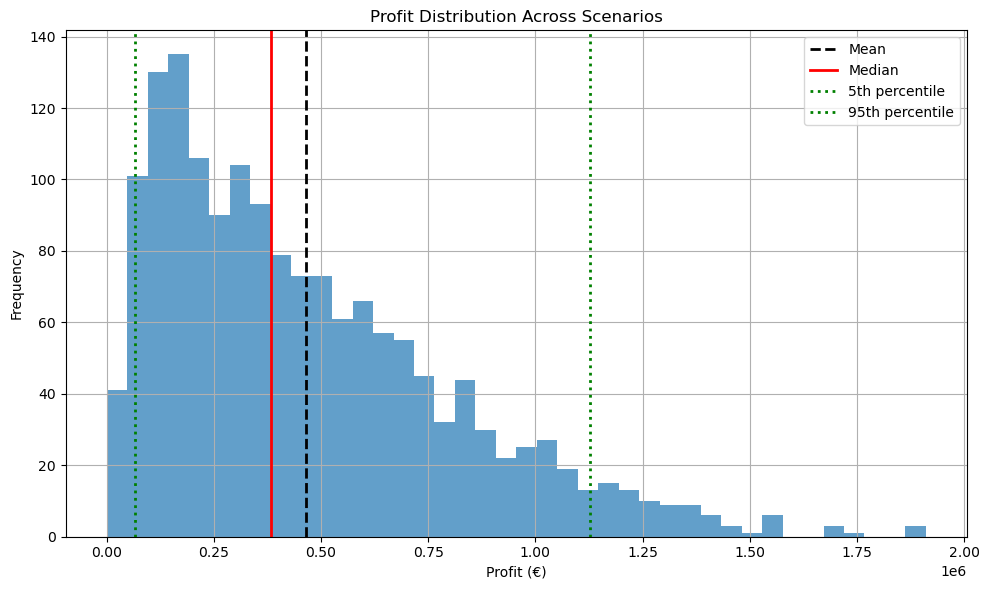

In [11]:
# ============================================
# IMPROVED PROFIT DISTRIBUTION PLOT
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# COMPUTE PROFIT PER SCENARIO
# ----------------------------
profits = np.zeros(N_total)

for w in range(N_total):
    for t in range(T):
        profits[w] += (
            p_opt[t] * lambda_DA_full[t, w]
            + (W_full[t, w] - p_opt[t]) * lambda_B_full[t, w]
        )

# ----------------------------
# STATISTICS
# ----------------------------
mean_profit = profits.mean()
std_profit = profits.std()
p5, p50, p95 = np.percentile(profits, [5, 50, 95])

print(f"Mean: {mean_profit:.2f}")
print(f"Std: {std_profit:.2f}")
print(f"5th percentile: {p5:.2f}")
print(f"Median: {p50:.2f}")
print(f"95th percentile: {p95:.2f}")

plt.figure(figsize=(10,6))

# Histogram
plt.hist(profits, bins=40, alpha=0.7)

# Lines with clear colors
plt.axvline(mean_profit, linestyle='--', linewidth=2, color='black', label="Mean")
plt.axvline(p50, linestyle='-', linewidth=2, color='red', label="Median")
plt.axvline(p5, linestyle=':', linewidth=2, color='green', label="5th percentile")
plt.axvline(p95, linestyle=':', linewidth=2, color='green', label="95th percentile")

# Labels
plt.xlabel("Profit (€)")
plt.ylabel("Frequency")
plt.title("Profit Distribution Across Scenarios")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# Task 1.2 — Offering Strategy under Two-Price Balancing Scheme

We extend the stochastic offering strategy to a two-price balancing mechanism.

---

## Key Difference from One-Price Scheme

Under the two-price scheme, imbalance settlement depends on whether the deviation is:

- **Helpful** to the system → settled at balancing price  
- **Harmful** to the system → settled at day-ahead price  

This introduces **asymmetric penalties** and removes arbitrage opportunities from imbalance creation.

---

## Decomposition of Deviations

We define:

$$
W_{t,\omega} - p_t^{DA} = \Delta^+_{t,\omega} - \Delta^-_{t,\omega}
$$

where:

- $\Delta^+_{t,\omega} = \max(W_{t,\omega} - p_t^{DA}, 0)$ (overproduction)
- $\Delta^-_{t,\omega} = \max(p_t^{DA} - W_{t,\omega}, 0)$ (underproduction)

---

## Profit Function

### Case 1: System Deficit ($SI = 1$)

- Overproduction ($\Delta^+ > 0$) → **helpful** → settled at balancing price  
- Underproduction ($\Delta^- > 0$) → **harmful** → settled at day-ahead price  

$$
\Pi_{t,\omega} =
p_t^{DA} \lambda^{DA}_{t,\omega}
+
\Delta^+_{t,\omega} \lambda^{B}_{t,\omega}
-
\Delta^-_{t,\omega} \lambda^{DA}_{t,\omega}
$$

---

### Case 2: System Surplus ($SI = 0$)

- Overproduction ($\Delta^+ > 0$) → **harmful** → settled at day-ahead price  
- Underproduction ($\Delta^- > 0$) → **helpful** → settled at balancing price  

$$
\Pi_{t,\omega} =
p_t^{DA} \lambda^{DA}_{t,\omega}
+
\Delta^+_{t,\omega} \lambda^{DA}_{t,\omega}
-
\Delta^-_{t,\omega} \lambda^{B}_{t,\omega}
$$

---

## Objective Function

We maximize expected profit across all scenarios:

$$
\max \ \mathbb{E}[\Pi] =
\frac{1}{|\Omega|}
\sum_{\omega \in \Omega} \sum_{t=1}^{24}
\Pi_{t,\omega}
$$

---

## Interpretation

Under the two-price scheme:

- Harmful deviations are penalized  
- Helpful deviations are rewarded  
- There is no incentive to deliberately create imbalances  

As a result:

- The optimal strategy becomes **risk-aware**
- The producer avoids extreme (0 or $P_{\max}$) bids
- The problem resembles a **newsvendor trade-off**, balancing:

  - Overproduction risk (penalty in surplus)
  - Underproduction risk (penalty in deficit)

This leads to smoother and more realistic offering strategies compared to the one-price scheme.

In [12]:
# ============================================
# TASK 1.2 — TWO-PRICE OPTIMIZATION (FINAL)
# ============================================

import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

# ----------------------------
# MODEL
# ----------------------------
model = gp.Model("two_price")

# Decision variable
p_DA = model.addVars(T, lb=0, ub=P_max, name="p_DA")

# SAFE variable names (avoid overwrite bugs)
delta_plus_var  = model.addVars(T, N_total, lb=0, ub=P_max, name="dp")
delta_minus_var = model.addVars(T, N_total, lb=0, ub=P_max, name="dm")

# ----------------------------
# LINK DEVIATIONS
# ----------------------------
for t in range(T):
    for w in range(N_total):
        model.addConstr(
            delta_plus_var[t,w] - delta_minus_var[t,w] == W_full[t,w] - p_DA[t]
        )

# ----------------------------
# OBJECTIVE
# ----------------------------
profit = 0

for t in range(T):
    for w in range(N_total):

        if SI_full[t,w] == 1:
            profit += (
                p_DA[t] * lambda_DA_full[t,w]
                + delta_plus_var[t,w] * lambda_B_full[t,w]
                - delta_minus_var[t,w] * lambda_DA_full[t,w]
            )
        else:
            profit += (
                p_DA[t] * lambda_DA_full[t,w]
                + delta_plus_var[t,w] * lambda_DA_full[t,w]
                - delta_minus_var[t,w] * lambda_B_full[t,w]
            )

profit = profit / N_total

model.setObjective(profit, GRB.MAXIMIZE)

# ----------------------------
# SOLVE
# ----------------------------
model.setParam("OutputFlag", 0)
model.optimize()

print("Status:", model.Status)

# ----------------------------
# RESULTS
# ----------------------------
if model.Status == GRB.OPTIMAL:

    p_opt_two = np.array([p_DA[t].X for t in range(T)])
    results_two_df = pd.DataFrame({
        "Hour": np.arange(T),
        "Optimal_DA_Offer_TwoPrice": p_opt_two
    })

    print(results_two_df)
    print("Expected Profit (model):", model.objVal)

else:
    raise ValueError("Model not optimal")

GurobiError: Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information

Expected Profit (simulation): 638.5142412974496


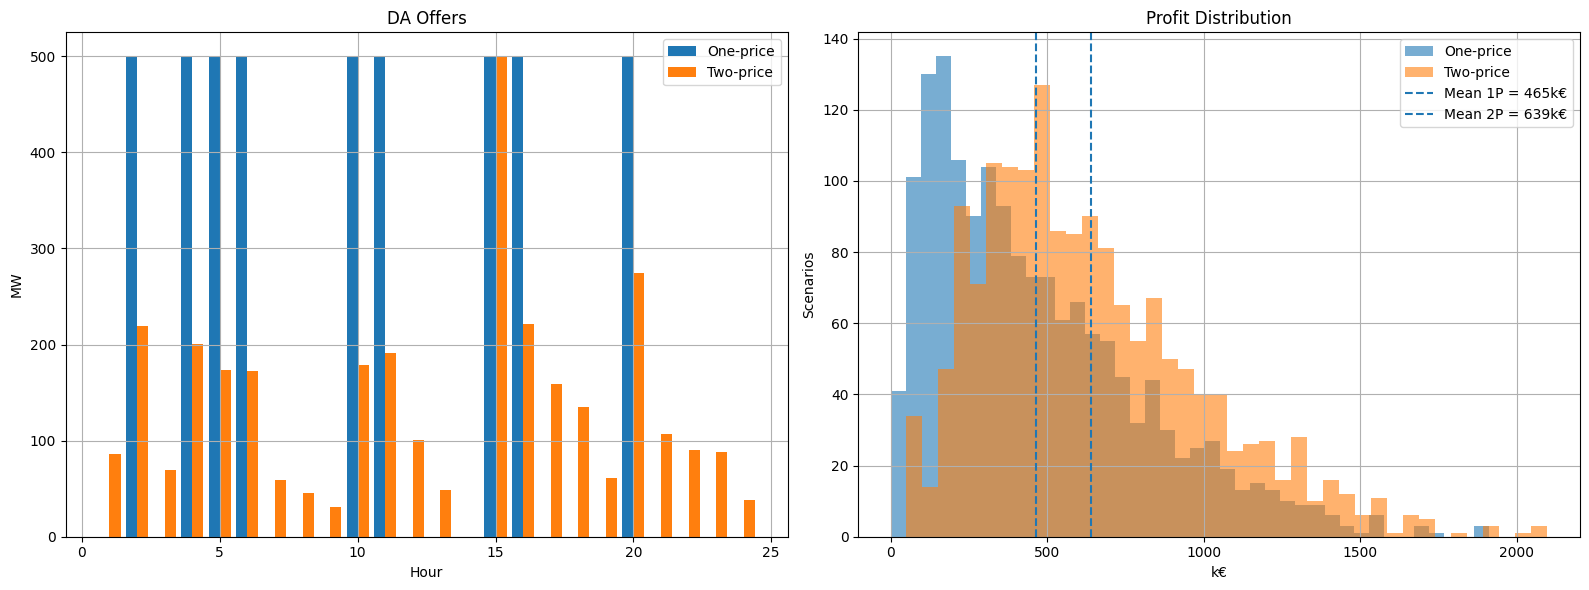

In [ ]:
# ============================================
# PROFIT COMPUTATION (CORRECT)
# ============================================

profits_2P = np.zeros(N_total)

for w in range(N_total):
    for t in range(T):

        dp = delta_plus_var[t,w].X
        dm = delta_minus_var[t,w].X

        if SI_full[t,w] == 1:
            profits_2P[w] += (
                p_opt_two[t] * lambda_DA_full[t,w]
                + dp * lambda_B_full[t,w]
                - dm * lambda_DA_full[t,w]
            )
        else:
            profits_2P[w] += (
                p_opt_two[t] * lambda_DA_full[t,w]
                + dp * lambda_DA_full[t,w]
                - dm * lambda_B_full[t,w]
            )

# convert to k€
profits_2P = profits_2P / 1000

print("Expected Profit (simulation):", profits_2P.mean())

# ============================================
# ONE-PRICE PROFITS (for comparison)
# ============================================

profits_1P = np.zeros(N_total)

for w in range(N_total):
    for t in range(T):
        profits_1P[w] += (
            p_opt[t] * lambda_DA_full[t,w]
            + (W_full[t,w] - p_opt[t]) * lambda_B_full[t,w]
        )

profits_1P = profits_1P / 1000

# ============================================
# PLOT
# ============================================

hours = np.arange(1, T+1)

fig, axes = plt.subplots(1,2, figsize=(16,6))

# ---- DA OFFERS
axes[0].bar(hours-0.2, p_opt, 0.4, label="One-price")
axes[0].bar(hours+0.2, p_opt_two, 0.4, label="Two-price")
axes[0].set_title("DA Offers")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("MW")
axes[0].legend()
axes[0].grid()

# ---- PROFIT
axes[1].hist(profits_1P, bins=40, alpha=0.6, label="One-price")
axes[1].hist(profits_2P, bins=40, alpha=0.6, label="Two-price")

axes[1].axvline(profits_1P.mean(), linestyle='--',
                label=f"Mean 1P = {profits_1P.mean():.0f}k€")
axes[1].axvline(profits_2P.mean(), linestyle='--',
                label=f"Mean 2P = {profits_2P.mean():.0f}k€")

axes[1].set_title("Profit Distribution")
axes[1].set_xlabel("k€")
axes[1].set_ylabel("Scenarios")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

## Summary Comparison — One-Price vs Two-Price Scheme

Table X presents a comparison of the optimal offering strategies under the one-price and two-price balancing schemes.

Contrary to the typical expectation, the **two-price scheme yields a higher expected profit**, increasing from 465 € to 639 € (+37.4%). This indicates that, under the given scenario set, the wind producer benefits from a more accurate alignment between its offering strategy and the realized system conditions.

In addition to higher profitability, the two-price scheme also leads to a **shift in the entire profit distribution**:

- The **lower tail improves significantly**, with the P10 increasing from 103 € to 243 €, indicating reduced downside risk.
- The **upper tail also increases**, with the P90 rising from 963 € to 1,148 €, showing improved upside potential.
- The minimum profit increases from 1 € to 48 €, confirming a reduction in extreme adverse outcomes.

However, the standard deviation remains slightly higher under the two-price scheme (355 € vs 341 €), suggesting that while worst-case outcomes improve, variability is not necessarily reduced.

From a strategic perspective, the most notable difference is in the **structure of the bidding behavior**:

- Under the one-price scheme, the solution exhibits strong **bang-bang behavior**, with 15 hours at 0 MW and 9 hours at full capacity.
- Under the two-price scheme, this behavior almost disappears, with only 1 hour at each extreme, indicating a **transition to smoother and more balanced bidding decisions**.

Overall, the two-price mechanism leads to a more refined and adaptive offering strategy, improving both expected profitability and robustness against unfavorable scenarios, while eliminating the incentive for extreme bidding behavior.

In [ ]:
# ============================================
# SUMMARY COMPARISON TABLE (FINAL)
# ============================================

# Ensure naming consistency
profits_1p = profits_1P
profits_2p = profits_2P
p_opt_1p = p_opt
p_opt_2p = p_opt_two

summary = pd.DataFrame({
    'Metric': [
        'Expected profit (€)',
        'Std of profit (€)',
        'P10 — worst 10% (€)',
        'P90 — best 10% (€)',
        'Min profit (€)',
        'Max profit (€)',
        'Hours at 0 MW',
        'Hours at 500 MW'
    ],
    'One-Price (Task 1.1)': [
        f'{profits_1p.mean():,.0f}',
        f'{profits_1p.std():,.0f}',
        f'{np.percentile(profits_1p, 10):,.0f}',
        f'{np.percentile(profits_1p, 90):,.0f}',
        f'{profits_1p.min():,.0f}',
        f'{profits_1p.max():,.0f}',
        int(np.sum(p_opt_1p < 1)),
        int(np.sum(p_opt_1p > 499))
    ],
    'Two-Price (Task 1.2)': [
        f'{profits_2p.mean():,.0f}',
        f'{profits_2p.std():,.0f}',
        f'{np.percentile(profits_2p, 10):,.0f}',
        f'{np.percentile(profits_2p, 90):,.0f}',
        f'{profits_2p.min():,.0f}',
        f'{profits_2p.max():,.0f}',
        int(np.sum(p_opt_2p < 1)),
        int(np.sum(p_opt_2p > 499))
    ]
})

print(summary.to_string(index=False))

# ----------------------------
# Profit comparison
# ----------------------------
profit_diff = profits_2p.mean() - profits_1p.mean()
profit_ratio = (profits_2p.mean() / profits_1p.mean() - 1) * 100

print("\n--- Profit Comparison ---")
print(f"Absolute difference: {profit_diff:,.0f} €")
print(f"Relative change: {profit_ratio:+.2f}%")

             Metric One-Price (Task 1.1) Two-Price (Task 1.2)
Expected profit (€)                  465                  639
  Std of profit (€)                  341                  355
P10 — worst 10% (€)                  103                  243
 P90 — best 10% (€)                  963                1,148
     Min profit (€)                    1                   48
     Max profit (€)                1,911                2,096
      Hours at 0 MW                   15                    1
    Hours at 500 MW                    9                    1

--- Profit Comparison ---
Absolute difference: 174 €
Relative change: +37.43%
